In [1]:
# Notebook with DL for Python - Chollet - for regualr time series with other features

In [2]:
# Just want to make sure the problem we have is similar to what happense over here in this dataset. We can do a last layer with dense 7 neurons, or the architecture we have in the other 7 notebook. Let's compare between these two models and chose what is the best one?

In [3]:
# !wget https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip

In [4]:
# !unzip jena_climate_2009_2016.csv.zip

In [5]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

2025-06-25 11:30:05.221223: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-25 11:30:05.257543: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-25 11:30:05.257566: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-25 11:30:05.258374: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-25 11:30:05.264028: I tensorflow/core/platform/cpu_feature_guar

In [6]:
fname = os.path.join("jena_climate_2009_2016.csv")

with open(fname) as f:
    data = f.read()

lines = data.split("\n")
header = lines[0].split(",")
lines = lines[1:]
print(header)
print(len(lines))

['"Date Time"', '"p (mbar)"', '"T (degC)"', '"Tpot (K)"', '"Tdew (degC)"', '"rh (%)"', '"VPmax (mbar)"', '"VPact (mbar)"', '"VPdef (mbar)"', '"sh (g/kg)"', '"H2OC (mmol/mol)"', '"rho (g/m**3)"', '"wv (m/s)"', '"max. wv (m/s)"', '"wd (deg)"']
420451


In [7]:
# there are 420451 obs, gathered every 10 minutes. The task is to predict the weather in 24 hours - the output for each line will be a singe one.

In [8]:
len(header)

15

In [9]:
# convert the data to numpy arrays. 1 for the temperature, and the other for the rest of the data

In [10]:
temperature = np.zeros((len(lines),))
raw_data = np.zeros((len(lines), len(header) - 1))

temperature.shape, raw_data.shape

((420451,), (420451, 14))

In [11]:
for i, line in enumerate(lines):
    
    # ignore the time step
    values = [float(x) for x in line.split(",")[1:]]
    # temperature is the value at position 1
    temperature[i] = values[1]
    # get all the rest of the data
    raw_data[i, :] = values[:]

In [12]:
temperature.shape

(420451,)

In [13]:
raw_data.shape

(420451, 14)

In [14]:
# plot the tempeature over time

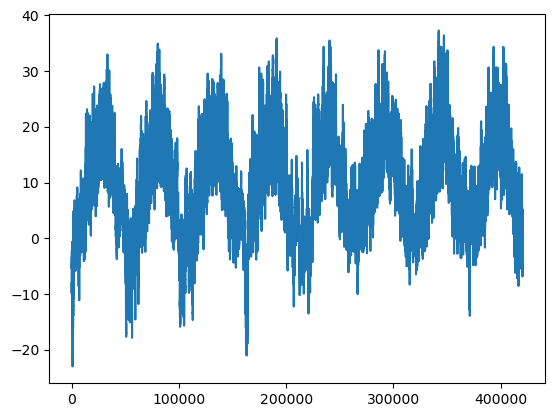

In [15]:
plt.plot(range(len(temperature)), temperature)
plt.show()

In [16]:
# A more narrow plot for the first 10 days (we have 6 measure for each hour)
10*6*24

1440

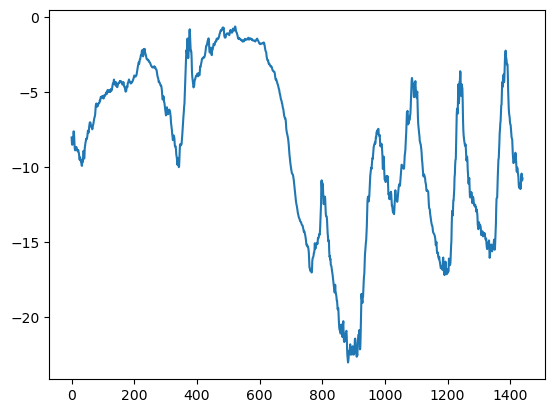

In [17]:
plt.plot(range(1440), temperature[:1440])
plt.show()

In [18]:
# Do 50-25-25 train-valid-test splits

In [19]:
num_train_samples = int(0.5 * len(raw_data))
num_val_samples = int(0.25 * len(raw_data))
num_test_samples = len(raw_data) - num_train_samples - num_val_samples
print("num_train_samples:", num_train_samples)
print("num_val_samples:", num_val_samples)
print("num_test_samples:", num_test_samples)

num_train_samples: 210225
num_val_samples: 105112
num_test_samples: 105114


##### Preparing the data

Exact problem formulation:  Given the data for the previous 5 days, sampled once per hour (from the 6), can we predict the temperature in the next 24 hours?

Need to conver the data into a format the NNs can ingest:

In [20]:
# First, normalize each time series independently - use the train data for this (like a fit transform)

In [21]:
mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean
std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std

In [22]:
# now we have the standardized data

In [23]:
# Now create a dataset object in the manner we need - use keras builtin generator for this - timeseries_dataset_from_array()

In [24]:
# Dummy dataset
int_sequence = np.arange(10)
dummy_dataset = tf.keras.utils.timeseries_dataset_from_array(
    data=int_sequence[:-3],
    targets=int_sequence[3:],
    sequence_length=3,
    batch_size=2,
)
dummy_dataset

2025-06-25 11:31:10.131167: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 31134 MB memory:  -> device: 0, name: Tesla V100S-PCIE-32GB, pci bus id: 0000:06:00.0, compute capability: 7.0


<_BatchDataset element_spec=(TensorSpec(shape=(None, None), dtype=tf.int64, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

In [25]:
for inputs, targets in dummy_dataset:
    for i in range(inputs.shape[0]):
        print([int(x) for x in inputs[i]], int(targets[i]))

[0, 1, 2] 3
[1, 2, 3] 4
[2, 3, 4] 5
[3, 4, 5] 6
[4, 5, 6] 7


Instantiating datasets for training, validation, and testing

In [26]:
sampling_rate = 6
sequence_length = 120
delay = sampling_rate * (sequence_length + 24 - 1)
batch_size = 256

In [27]:
train_dataset = tf.keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples)

val_dataset = tf.keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples)

test_dataset = tf.keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples + num_val_samples)

Inspecting the output of one of our datasets

In [28]:
for samples, targets in train_dataset:
    print("samples shape:", samples.shape)
    print("targets shape:", targets.shape)
    break

samples shape: (256, 120, 14)
targets shape: (256,)


In [29]:
# note that our features (samples) do include the temperature values also in the sequence

In [30]:
# Notice the data here (for features part) matches with what we have for inputs. The target in our case is the next 7 time steps. So I think it makes more sense with the encoder decoder architecture similar to the CNN LSTM model. 
# In our case, we do need to use the initial 13 time periods to predict the last 7 time periods for the LSTM, is that right? Because it is how the LSTM works? And we cannot use the constrcuted 7 features from the seq-2-seq model? Need to talk to Dr. G about this.

In [31]:
# Before using the DL models, they fit some common sense modedls, and ML models for the data, let's take a look

Base model 1 - Predict the temperature now as the same in 24 hours

In [32]:
def evaluate_naive_method(dataset):
    total_abs_err = 0.
    samples_seen = 0
    for samples, targets in dataset:
        preds = samples[:, -1, 1] * std[1] + mean[1] # - std[1], mean[1] are the std and mean of temperature - have to do this as we had standardized the data
        total_abs_err += np.sum(np.abs(preds - targets))
        samples_seen += samples.shape[0]
    return total_abs_err / samples_seen

print(f"Validation MAE: {evaluate_naive_method(val_dataset):.2f}")
print(f"Test MAE: {evaluate_naive_method(test_dataset):.2f}")

Validation MAE: 2.44
Test MAE: 2.62


In [33]:
len(std), len(mean)

(14, 14)

These are the values to beat

Base model 2 - Dense NN - reshape the featrues for the input

In [34]:
inputs = tf.keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = tf.keras.layers.Flatten()(inputs)
x = tf.keras.layers.Dense(16, activation="relu")(x)
outputs = tf.keras.layers.Dense(1)(x)
model = tf.keras.Model(inputs, outputs)

In [35]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 120, 14)]         0         
                                                                 
 flatten (Flatten)           (None, 1680)              0         
                                                                 
 dense (Dense)               (None, 16)                26896     
                                                                 
 dense_1 (Dense)             (None, 1)                 17        
                                                                 
Total params: 26913 (105.13 KB)
Trainable params: 26913 (105.13 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [36]:
callbacks = [tf.keras.callbacks.ModelCheckpoint("jena_dense.keras", save_best_only=True)]

model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)

Epoch 1/10


2025-06-25 11:31:17.206963: I external/local_xla/xla/service/service.cc:168] XLA service 0x148b98714430 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-06-25 11:31:17.207012: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): Tesla V100S-PCIE-32GB, Compute Capability 7.0
2025-06-25 11:31:17.216072: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-06-25 11:31:17.229306: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
I0000 00:00:1750869077.302470 2358237 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


819/819 [==============================] - 8s 8ms/step - loss: 16.5865 - mae: 3.1124 - val_loss: 10.8821 - val_mae: 2.5881
Epoch 2/10
819/819 [==============================] - 7s 8ms/step - loss: 10.2792 - mae: 2.5288 - val_loss: 11.0523 - val_mae: 2.6277
Epoch 3/10
819/819 [==============================] - 7s 8ms/step - loss: 9.3377 - mae: 2.4076 - val_loss: 12.0218 - val_mae: 2.7425
Epoch 4/10
819/819 [==============================] - 7s 8ms/step - loss: 8.7355 - mae: 2.3294 - val_loss: 10.4490 - val_mae: 2.5428
Epoch 5/10
819/819 [==============================] - 7s 8ms/step - loss: 8.2873 - mae: 2.2666 - val_loss: 11.8743 - val_mae: 2.7252
Epoch 6/10
819/819 [==============================] - 7s 8ms/step - loss: 7.9681 - mae: 2.2215 - val_loss: 12.0184 - val_mae: 2.7366
Epoch 7/10
819/819 [==============================] - 7s 8ms/step - loss: 7.7253 - mae: 2.1880 - val_loss: 12.7992 - val_mae: 2.8394
Epoch 8/10
819/819 [==============================] - 7s 8ms/step - loss: 7.52

In [37]:
model = tf.keras.models.load_model("jena_dense.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

405/405 [==============================] - 2s 5ms/step - loss: 11.1198 - mae: 2.5963
Test MAE: 2.60


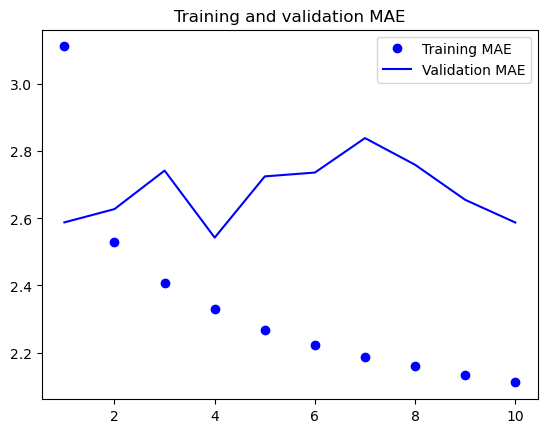

In [38]:
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

Base model 3 - 1D convnet

In [39]:
inputs = tf.keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = tf.keras.layers.Conv1D(8, 24, activation="relu")(inputs)
x = tf.keras.layers.MaxPooling1D(2)(x)
x = tf.keras.layers.Conv1D(8, 12, activation="relu")(x)
x = tf.keras.layers.MaxPooling1D(2)(x)
x = tf.keras.layers.Conv1D(8, 6, activation="relu")(x)
x = tf.keras.layers.GlobalAveragePooling1D()(x)
outputs = tf.keras.layers.Dense(1)(x)
model = tf.keras.Model(inputs, outputs)

In [40]:
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 120, 14)]         0         
                                                                 
 conv1d (Conv1D)             (None, 97, 8)             2696      
                                                                 
 max_pooling1d (MaxPooling1  (None, 48, 8)             0         
 D)                                                              
                                                                 
 conv1d_1 (Conv1D)           (None, 37, 8)             776       
                                                                 
 max_pooling1d_1 (MaxPoolin  (None, 18, 8)             0         
 g1D)                                                            
                                                                 
 conv1d_2 (Conv1D)           (None, 13, 8)             392 

In [41]:
callbacks = [tf.keras.callbacks.ModelCheckpoint("jena_conv.keras",save_best_only=True)]

model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)

Epoch 1/10
819/819 [==============================] - 8s 9ms/step - loss: 24.0180 - mae: 3.7884 - val_loss: 17.2896 - val_mae: 3.2586
Epoch 2/10
819/819 [==============================] - 7s 8ms/step - loss: 15.0176 - mae: 3.0822 - val_loss: 15.8944 - val_mae: 3.1585
Epoch 3/10
819/819 [==============================] - 7s 8ms/step - loss: 13.6572 - mae: 2.9298 - val_loss: 14.4208 - val_mae: 3.0043
Epoch 4/10
819/819 [==============================] - 7s 8ms/step - loss: 12.7792 - mae: 2.8283 - val_loss: 15.5029 - val_mae: 3.1068
Epoch 5/10
819/819 [==============================] - 7s 8ms/step - loss: 12.0971 - mae: 2.7511 - val_loss: 14.7025 - val_mae: 3.0313
Epoch 6/10
819/819 [==============================] - 7s 8ms/step - loss: 11.6031 - mae: 2.6907 - val_loss: 15.0683 - val_mae: 3.0934
Epoch 7/10
819/819 [==============================] - 7s 8ms/step - loss: 11.2018 - mae: 2.6440 - val_loss: 15.4336 - val_mae: 3.1015
Epoch 8/10
819/819 [==============================] - 7s 8ms/s

In [42]:
model = tf.keras.models.load_model("jena_conv.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

405/405 [==============================] - 2s 5ms/step - loss: 15.4669 - mae: 3.1042
Test MAE: 3.10


LSTM-based model

In [43]:
inputs = tf.keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = tf.keras.layers.LSTM(16)(inputs)
outputs = tf.keras.layers.Dense(1)(x)
model = tf.keras.Model(inputs, outputs)

In [44]:
model.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 120, 14)]         0         
                                                                 
 lstm (LSTM)                 (None, 16)                1984      
                                                                 
 dense_3 (Dense)             (None, 1)                 17        
                                                                 
Total params: 2001 (7.82 KB)
Trainable params: 2001 (7.82 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [45]:
callbacks = [tf.keras.callbacks.ModelCheckpoint("jena_lstm.keras", save_best_only=True)]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)

Epoch 1/10
819/819 [==============================] - 8s 9ms/step - loss: 36.3966 - mae: 4.3923 - val_loss: 11.6231 - val_mae: 2.6151
Epoch 2/10
819/819 [==============================] - 7s 8ms/step - loss: 10.5719 - mae: 2.5343 - val_loss: 9.7337 - val_mae: 2.4150
Epoch 3/10
819/819 [==============================] - 7s 8ms/step - loss: 9.6495 - mae: 2.4208 - val_loss: 9.4986 - val_mae: 2.3816
Epoch 4/10
819/819 [==============================] - 7s 8ms/step - loss: 9.0927 - mae: 2.3461 - val_loss: 9.5046 - val_mae: 2.3808
Epoch 5/10
819/819 [==============================] - 7s 8ms/step - loss: 8.6947 - mae: 2.2953 - val_loss: 9.3053 - val_mae: 2.3558
Epoch 6/10
819/819 [==============================] - 7s 8ms/step - loss: 8.4224 - mae: 2.2633 - val_loss: 9.4595 - val_mae: 2.3834
Epoch 7/10
819/819 [==============================] - 7s 8ms/step - loss: 8.1615 - mae: 2.2292 - val_loss: 9.6564 - val_mae: 2.4118
Epoch 8/10
819/819 [==============================] - 7s 8ms/step - loss:

In [46]:
model = tf.keras.models.load_model("jena_lstm.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

405/405 [==============================] - 3s 5ms/step - loss: 10.4453 - mae: 2.5306
Test MAE: 2.53


In [47]:
# Finally this beats the baseline

dropout-regularizes LSTM

In [48]:
inputs = tf.keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = tf.keras.layers.LSTM(32, recurrent_dropout=0.25)(inputs)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(1)(x)
model = tf.keras.Model(inputs, outputs)

In [49]:
model.summary()

Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 120, 14)]         0         
                                                                 
 lstm_1 (LSTM)               (None, 32)                6016      
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense_4 (Dense)             (None, 1)                 33        
                                                                 
Total params: 6049 (23.63 KB)
Trainable params: 6049 (23.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [50]:
callbacks = [tf.keras.callbacks.ModelCheckpoint("jena_lstm_dropout.keras", save_best_only=True)]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)

Epoch 1/10
819/819 [==============================] - 164s 197ms/step - loss: 27.7930 - mae: 3.8879 - val_loss: 10.1797 - val_mae: 2.4828
Epoch 2/10
819/819 [==============================] - 162s 198ms/step - loss: 14.9579 - mae: 3.0008 - val_loss: 9.4834 - val_mae: 2.4029
Epoch 3/10
819/819 [==============================] - 163s 199ms/step - loss: 13.9877 - mae: 2.8948 - val_loss: 9.4259 - val_mae: 2.3890
Epoch 4/10
819/819 [==============================] - 162s 198ms/step - loss: 13.2688 - mae: 2.8248 - val_loss: 9.0751 - val_mae: 2.3403
Epoch 5/10
819/819 [==============================] - 162s 198ms/step - loss: 12.7474 - mae: 2.7699 - val_loss: 8.9802 - val_mae: 2.3266
Epoch 6/10
819/819 [==============================] - 162s 197ms/step - loss: 12.3604 - mae: 2.7270 - val_loss: 9.0350 - val_mae: 2.3321
Epoch 7/10
819/819 [==============================] - 162s 198ms/step - loss: 12.0285 - mae: 2.6890 - val_loss: 9.1105 - val_mae: 2.3447
Epoch 8/10
819/819 [====================

In [52]:
model = tf.keras.models.load_model("jena_lstm_dropout.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

405/405 [==============================] - 14s 33ms/step - loss: 10.1815 - mae: 2.5264
Test MAE: 2.53


Stacked recurrent model

In [53]:
inputs = tf.keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = tf.keras.layers.GRU(32, recurrent_dropout=0.5, return_sequences=True)(inputs)
x = tf.keras.layers.GRU(32, recurrent_dropout=0.5)(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(1)(x)
model = tf.keras.Model(inputs, outputs)

In [54]:
model.summary()

Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 120, 14)]         0         
                                                                 
 gru (GRU)                   (None, 120, 32)           4608      
                                                                 
 gru_1 (GRU)                 (None, 32)                6336      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense_5 (Dense)             (None, 1)                 33        
                                                                 
Total params: 10977 (42.88 KB)
Trainable params: 10977 (42.88 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [55]:
callbacks = [tf.keras.callbacks.ModelCheckpoint("jena_stacked_gru_dropout.keras",
                                    save_best_only=True)]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)

Epoch 1/10
819/819 [==============================] - 295s 357ms/step - loss: 23.9590 - mae: 3.6293 - val_loss: 9.1957 - val_mae: 2.3491
Epoch 2/10
819/819 [==============================] - 293s 357ms/step - loss: 14.0624 - mae: 2.9055 - val_loss: 8.7757 - val_mae: 2.3015
Epoch 3/10
819/819 [==============================] - 290s 354ms/step - loss: 13.2743 - mae: 2.8232 - val_loss: 8.6318 - val_mae: 2.2759
Epoch 4/10
819/819 [==============================] - 293s 358ms/step - loss: 12.6953 - mae: 2.7618 - val_loss: 8.8878 - val_mae: 2.3190
Epoch 5/10
819/819 [==============================] - 290s 354ms/step - loss: 12.2342 - mae: 2.7111 - val_loss: 9.0738 - val_mae: 2.3451
Epoch 6/10
819/819 [==============================] - 287s 350ms/step - loss: 11.8195 - mae: 2.6676 - val_loss: 9.4599 - val_mae: 2.4183
Epoch 7/10
819/819 [==============================] - 284s 347ms/step - loss: 11.3712 - mae: 2.6162 - val_loss: 9.0540 - val_mae: 2.3425
Epoch 8/10
819/819 [=====================

In [56]:
model = tf.keras.models.load_model("jena_stacked_gru_dropout.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

405/405 [==============================] - 20s 48ms/step - loss: 9.6477 - mae: 2.4229
Test MAE: 2.42


Bidirectional RNN

In [58]:
inputs = tf.keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(16))(inputs)
outputs = tf.keras.layers.Dense(1)(x)
model = tf.keras.Model(inputs, outputs)

In [59]:
model.summary()

Model: "model_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_7 (InputLayer)        [(None, 120, 14)]         0         
                                                                 
 bidirectional (Bidirection  (None, 32)                3968      
 al)                                                             
                                                                 
 dense_6 (Dense)             (None, 1)                 33        
                                                                 
Total params: 4001 (15.63 KB)
Trainable params: 4001 (15.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [60]:
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset)

Epoch 1/10
819/819 [==============================] - 11s 11ms/step - loss: 26.4268 - mae: 3.7015 - val_loss: 10.6289 - val_mae: 2.5205
Epoch 2/10
819/819 [==============================] - 9s 10ms/step - loss: 9.3406 - mae: 2.3862 - val_loss: 10.4233 - val_mae: 2.4998
Epoch 3/10
819/819 [==============================] - 9s 10ms/step - loss: 8.4711 - mae: 2.2744 - val_loss: 10.1701 - val_mae: 2.4682
Epoch 4/10
819/819 [==============================] - 9s 10ms/step - loss: 7.8619 - mae: 2.1936 - val_loss: 10.3693 - val_mae: 2.4907
Epoch 5/10
819/819 [==============================] - 8s 10ms/step - loss: 7.3757 - mae: 2.1282 - val_loss: 10.4500 - val_mae: 2.5038
Epoch 6/10
819/819 [==============================] - 9s 10ms/step - loss: 7.0133 - mae: 2.0764 - val_loss: 11.1945 - val_mae: 2.5852
Epoch 7/10
819/819 [==============================] - 8s 10ms/step - loss: 6.7519 - mae: 2.0380 - val_loss: 11.0386 - val_mae: 2.5667
Epoch 8/10
819/819 [==============================] - 8s 10m

In [61]:
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

405/405 [==============================] - 2s 5ms/step - loss: 11.7039 - mae: 2.7017
Test MAE: 2.70
